In [ ]:
import os
import re
import subprocess
from pathlib import Path
import pandas as pd
from Bio.PDB import PDBParser, MMCIFParser

### 对天然的结构进行预测后采用DockQ对所有预测结果进行打分

In [7]:
import os
import sys

from numpy import full

with open('/home/junjiechen/1_work/250401-Dpepalign/Benchmark/dataset/PepSet_dimer/PDB.list', 'r') as f:
    pdbs = [pdb.strip() for pdb in f.readlines()]

with open('pred_v1_nomsa_template.list', 'w') as f:
    for pdb in pdbs:
        pred_path = '/home/junjiechen/1_work/250401-Dpepalign/Benchmark/protenix/PepSet/pred_v1_nomsa_template'
        for seed in ['seed_42', 'seed_43', 'seed_44']:
            full_path = os.path.join(pred_path, pdb, seed, 'predictions')
            for i in range(5):
                dockq_cmd = f'DockQ {full_path}/{pdb}_sample_{i}.cif /home/junjiechen/1_work/250401-Dpepalign/Benchmark/dataset/PepSet_dimer/{pdb}.pdb --short --allowed_mismatches 20 --mapping BA:L*'    # 注意，采用mapping时，固定的链需要放在前面
                f.write(dockq_cmd + '\n')



## 分析DockQ的输出out.log与预测结构的多肽链plddt之间的关系

In [ ]:
import pandas as pd
import json

df = pd.DataFrame(columns=['model', 'seed', 'dockq_score', 'ranking_score', 'pep_plddt', 'iptm', 'irmsd', 'lrmsd', 'fnat', 'native'])
method = 'pred_v1_nomsa_template'
with open(f'/home/junjiechen/1_work/250401-Dpepalign/Benchmark/protenix/PepSet/DockQ/out/{method}.out', 'r') as f:
    lines = f.readlines()


for i, line in enumerate(lines):
    if i % 2 == 1:
        parts = line.strip().split()
        dockq_score = parts[1].strip()
        irmsd = parts[3].strip()
        lrmsd = parts[5].strip()
        fnat = parts[7].strip()
        model = parts[16].split('/')[-1].split(".")[0].strip()
        seed = parts[16].split('/')[-3].split(".")[0].strip()
        native = parts[20].split('/')[-1].strip()

        pdb = native.replace('.pdb', '')
        id = model.split('_')[-1]
        pred_json_path = f'../{method}/{pdb}/{seed}/predictions/{pdb}_summary_confidence_sample_{id}.json'
        with open(pred_json_path, 'r') as jf:
            pred_data = json.load(jf)
            pep_plddt = pred_data['chain_plddt'][1]
            ipTM = pred_data['iptm']
            ranking_score = pred_data['ranking_score']
            # You can use model_confidence if needed
        dict_row = {'model': model, 'seed': seed, 'dockq_score': dockq_score, 'ranking_score': ranking_score, 'pep_plddt': pep_plddt, 'iptm': ipTM, 'irmsd': irmsd, 'lrmsd': lrmsd, 'fnat': fnat, 'native': native}
        df = pd.concat([df, pd.DataFrame([dict_row])], ignore_index=True)

selected = 

fil_df = df[(df['dockq_score'].astype(float) >= 0.23) & (df['fnat'].astype(float) >= 0.8)]
count = fil_df['native'].nunique()
print(f'Number of unique native structures with DockQ >= 0.23: {count}')
# 将去重后的结果保存在unique_df中,重复的native保存dockq最高的5个结果
unique_df = fil_df.sort_values(by='dockq_score', ascending=False).groupby('native').head(1)
unique_df = unique_df.sort_values(by="model")
unique_df.to_csv(f'dockq_le0.23_protenix_{method}.csv', index=False)

/tmp/ipykernel_3291574/2428661800.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([dict_row])], ignore_index=True)


Number of unique native structures with DockQ >= 0.23: 121


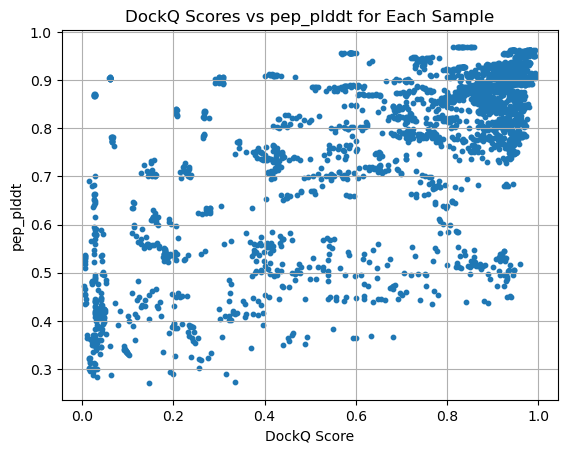

In [12]:
# best_models = df.loc[df.groupby('native')['dockq_score'].idxmax()]
import matplotlib.pyplot as plt

plt.scatter(df['dockq_score'].astype(float), df['pep_plddt'].astype(float), s=10, alpha=1)
plt.xlabel('DockQ Score')
plt.ylabel('pep_plddt')
plt.title('DockQ Scores vs pep_plddt for Each Sample')
plt.grid(True)
# plt.hlines(y=0.8, xmin=0, xmax=1, colors='r', linestyles='dashed', label='DockQ=0.8')
plt.show()

In [47]:
import os
import pandas as pd

with open('../dimer/PDB.list', 'r') as f:
    pdbs = [line.strip() for line in f if line.strip()]

# print(pdbs)
with open('../dimer_filtered/results-head5.txt', 'w') as result_file:
    for pdb in pdbs:
        df = pd.read_csv(f'../pred/{pdb}/metrics_summary.csv')
        fil_df = df[(df['scRMSD'] <= 2.5) & (df['plddt'] > 85) & (df['iptm'] > 0.7)].sort_values(by=['scRMSD'], ascending=True).reset_index(drop=True)
        # fil_df.to_csv(f'./pred/{pdb}/metrics_filtered_scRMSD_le25_plddt85_iptm07.csv', index=False)
        count = fil_df['complex'].nunique()
        # oricount = df['complex'].nunique()
        print(f"{pdb}: {count:>2}")
        if count == 1:
            # 将每一个pdb预测的top5吸入result_file
            for i in range(min(5, len(fil_df))):
                seed = fil_df.iloc[i]['seed']
                sample_id = str(fil_df.iloc[i]['id'])
                scRMSD = fil_df.iloc[i]['scRMSD']
                iptm = fil_df.iloc[i]['iptm']
                plddt = fil_df.iloc[i]['plddt']
                # os.system(f"cp ./pred/{pdb}/{seed}/predictions/{pdb}_sample_{sample_id}.cif ./dimer_filtered/{pdb}_sample_{sample_id}.cif")
                result_file.write(f"{pdb}_sample_{sample_id}_{seed}\n")

1a0n:  0
1cqg:  0
1czy:  1
1ddv:  0
1eg4:  0
1f47:  1
1f8h:  1
1j2x:  1
1jd5:  1
1jq8:  0
1jw6:  0
1l2z:  0
1lb6:  1
1mf4:  0
1mv0:  0
1nrl:  1
1nvq:  0
1o0p:  0
1p7v:  0
1pmx:  0
1r17:  1
1rxz:  1
1t74:  1
1v1t:  1
1w80:  1
1yfn:  0
1ywi:  1
1ywo:  1
1yy6:  1
2aij:  1
2aq9:  0
2c3i:  1
2cch:  1
2cny:  1
2e4h:  0
2fgr:  0
2fka:  1
2hpl:  1
2ht9:  0
2i94:  0
2ivz:  0
2jkg:  0
2jnw:  0
2jqk:  0
2ka9:  0
2kbr:  0
2ke1:  0
2khh:  0
2koh:  0
2las:  0
2lsi:  0
2m0v:  0
2nnu:  0
2o9v:  1
2p1o:  0
2qos:  1
2r7g:  1
2rol:  0
2v8c:  0
2vzg:  1
2xcb:  1
2xpn:  1
2xrw:  0
2ymt:  1
3agy:  0
3bej:  1
3bqo:  1
3emh:  1
3emw:  1
3et3:  1
3fp2:  0
3g2s:  1
3h1z:  0
3i5r:  1
3obq:  1
3p72:  1
3pe4:  0
3plu:  1
3r42:  0
3s9c:  0
3shb:  1
3tiw:  0
3v2o:  0
3wgx:  1
3zrj:  1
4a2a:  1
4bt9:  1
4c5a:  0
4dg3:  1
4ep2:  0
4fii:  1
4gq6:  1
4hdq:  1
4hom:  0
4iga:  1
4j2c:  1
4j8b:  1
4leb:  0
4lk9:  1
4lzf:  0
4m5s:  1
4m91:  0
4mvi:  0
4nuu:  1
4nxr:  1
4ny3:  1
4odk:  0
4ouc:  0
4oyk:  1
4pd1:  1
4pge:  1
4

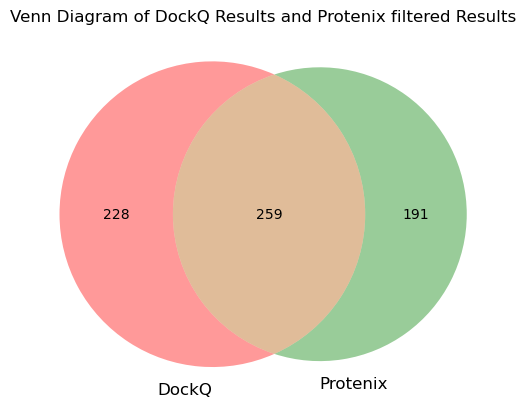

In [48]:
# 比较pdb_dockq.txt和/home/junjiechen/1_work/250401-Dpepalign/Benchmark/protenix/PepSet/dimer_filtered/results-head5.txt，绘制韦恩图
# %pip install matplotlib-venn

from matplotlib_venn import venn2
with open('pdb_dockq_head5.txt', 'r') as f:
    dockq_pdbs = set(line.strip() for line in f.readlines())
with open('/home/junjiechen/1_work/250401-Dpepalign/Benchmark/protenix/PepSet/dimer_filtered/results-head5.txt', 'r') as f:
    native_pdbs = set(line.strip() for line in f.readlines())
venn2([dockq_pdbs, native_pdbs], set_labels=('DockQ', 'Protenix'))
plt.title('Venn Diagram of DockQ Results and Protenix filtered Results')
plt.show()

## 对按照scRMSD、pep_pLDDT、ipTM进行筛选后得到的91个scRMSD最小的pdb进行DockQ打分

In [5]:
import os
import sys

from numpy import full

with open('/home/junjiechen/1_work/250401-Dpepalign/Benchmark/protenix/PepSet/dimer_filtered/PDB-pep_pLDDT.list', 'r') as f:
    pdbs = [pdb.strip() for pdb in f.readlines()]


with open('jobs-pep_pLDDT.txt', 'w') as f:
    for pred_pdb in pdbs:
        native_pdb = pred_pdb.split('_')[0]
        pred_path = '/home/junjiechen/1_work/250401-Dpepalign/Benchmark/protenix/PepSet/dimer_filtered'
        dockq_cmd = f'DockQ {pred_path}/{pred_pdb}.pdb /home/junjiechen/1_work/250401-Dpepalign/Benchmark/protenix/PepSet/dimer/{native_pdb}.pdb --short --allowed_mismatches 20 --mapping BA:L*'    # 注意，采用mapping时，固定的链需要放在前面
        f.write(dockq_cmd + '\n')


### 分析预测结果中DockQ值小于0.23,在0.23-0.49，0.49-0.80以及0.80以上的pdb个数

In [9]:
import pandas as pd
import json
import re

df = pd.DataFrame(columns=['model','dockq_score'])
with open('out-pep_pLDDT.log', 'r') as f:
    lines = f.readlines()



for i, line in enumerate(lines):
    if i % 2 == 1:
        parts = line.strip().split()
        dockq_score = parts[1].strip()
        model = parts[16].split('/')[-1].split(".")[0].strip()

        dict_row = {'model': model, 'dockq_score': dockq_score}
        df = pd.concat([df, pd.DataFrame([dict_row])], ignore_index=True)

df

,model,dockq_score
0,1j2x_sample_4,0.920
1,1czy_sample_1,0.962
2,1f47_sample_2,0.963
3,1lb6_sample_4,0.981
4,1t74_sample_3,0.950
...,...,...
86,6f0w_sample_0,0.874
87,6fbk_sample_2,0.892
88,6h7b_sample_1,0.914
89,6f6d_sample_2,0.871


In [10]:
# 分析预测结果中DockQ值小于0.23,在0.23-0.49，0.49-0.80以及0.80以上的pdb个数
bins = [0, 0.23, 0.49, 0.80, 1.0]
labels = ['<0.23', '0.23-0.49', '0.49-0.80', '>=0.80']
df['dockq_category'] = pd.cut(df['dockq_score'].astype(float), bins=bins, labels=labels, right=False)
category_counts = df['dockq_category'].value_counts().sort_index()
print(category_counts)

dockq_category
<0.23         0
0.23-0.49     0
0.49-0.80     6
>=0.80       85
Name: count, dtype: int64
